In [1]:
#Loading the data

import pandas as pd 
import numpy as np 

df = pd.read_csv('Prices-Export.csv')

df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 6663 entries, 0 to 6662
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               6663 non-null   str    
 1   Admin 1               6663 non-null   str    
 2   Admin 2               6663 non-null   str    
 3   Market Name           6663 non-null   str    
 4   Commodity             6663 non-null   str    
 5   Price Type            6663 non-null   str    
 6   Price Date            6663 non-null   str    
 7   Collection Frequency  6663 non-null   str    
 8   Price                 6663 non-null   float64
 9   Unit                  6663 non-null   str    
 10  Currency              6663 non-null   str    
 11  Data Source           6663 non-null   str    
 12  Trend                 3054 non-null   float64
 13  Pewi                  3054 non-null   float64
 14  ALPS Phase            3054 non-null   str    
 15  Data Type             6663 non-n

(6663, 19)

### Data Cleaning and Preprocessing

In [2]:
#Data Cleaning and Preprocessing
df.describe()
df.isnull().sum()

# drop only the listed columns that exist (ignore missing ones)
df = df.drop(columns=['Country','Collection Frequency','Currency','Data Source','Pewi','ALPS Phase','Data Type','Upper (95%) CI','Lower (95%) CI','Forecast Methodology','Trend'], errors='ignore')

df.head()


,Admin 1,Admin 2,Market Name,Commodity,Price Type,Price Date,Price,Unit
0,Coast,Tana River,Adele Center,Beans,Retail,15-09-24,160.0,KG
1,Coast,Tana River,Adele Center,Maize flour (white),Retail,15-09-24,70.0,KG
2,North Eastern,Garissa,Alango Arba,Beans,Retail,15-03-24,200.0,KG
3,North Eastern,Garissa,Alango Arba,Beans,Retail,15-06-24,200.0,KG
4,North Eastern,Garissa,Alango Arba,Beans,Retail,15-09-24,190.0,KG


# Standardize Column Names

In [3]:
#Standardize column names

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df.columns
df.dtypes

df['price_date'] =pd.to_datetime(df['price_date'])

df.dtypes
df['price_date'].min(), df['price_date'].max()

# Create year_month as a column in the dataframe
df['year_month'] = df['price_date'].dt.to_period('M')
print(df['year_month'])

0       2024-09
1       2024-09
2       2024-03
3       2024-06
4       2024-09
         ...   
6658    2024-03
6659    2024-06
6660    2024-09
6661    2024-12
6662    2025-03
Name: year_month, Length: 6663, dtype: period[M]


C:\Users\TEST\AppData\Local\Temp\ipykernel_8208\1113669798.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['price_date'] =pd.to_datetime(df['price_date'])


# Exploratory Data Analysis

In [4]:
#Exploratory data analysis
print(df['price_type'].value_counts())
print(df['commodity'].value_counts())

price_type
Retail    6663
Name: count, dtype: int64
commodity
Beans (dry)                   820
Oil (vegetable)               771
Rice                          754
Maize flour                   753
Maize                         694
Maize flour (white)           668
Oil (vegetable, fortified)    658
Beans                         570
Maize (white, dry)            484
Kale                          321
Maize (white)                 136
Milk (cow, fresh)              33
Tomatoes                        1
Name: count, dtype: int64


In [5]:


# Verify the filter worked
print(df['commodity'].value_counts())

commodity
Beans (dry)                   820
Oil (vegetable)               771
Rice                          754
Maize flour                   753
Maize                         694
Maize flour (white)           668
Oil (vegetable, fortified)    658
Beans                         570
Maize (white, dry)            484
Kale                          321
Maize (white)                 136
Milk (cow, fresh)              33
Tomatoes                        1
Name: count, dtype: int64


In [6]:

# Calculate the avg price for each commodity by month

monthly_avg_price = df.groupby([df['year_month'], 'commodity'])['price'].mean().reset_index()
print(monthly_avg_price)

    year_month        commodity       price
0      2020-01      Beans (dry)  100.250000
1      2020-01    Maize (white)   54.650000
2      2020-01  Oil (vegetable)  195.000000
3      2020-02      Beans (dry)   96.375000
4      2020-02    Maize (white)   53.833333
..         ...              ...         ...
381    2026-05      Beans (dry)  111.605400
382    2026-05            Maize   61.427992
383    2026-05      Maize flour   84.795550
384    2026-05  Oil (vegetable)  261.575950
385    2026-05             Rice  122.061033

[386 rows x 3 columns]


# Visualization

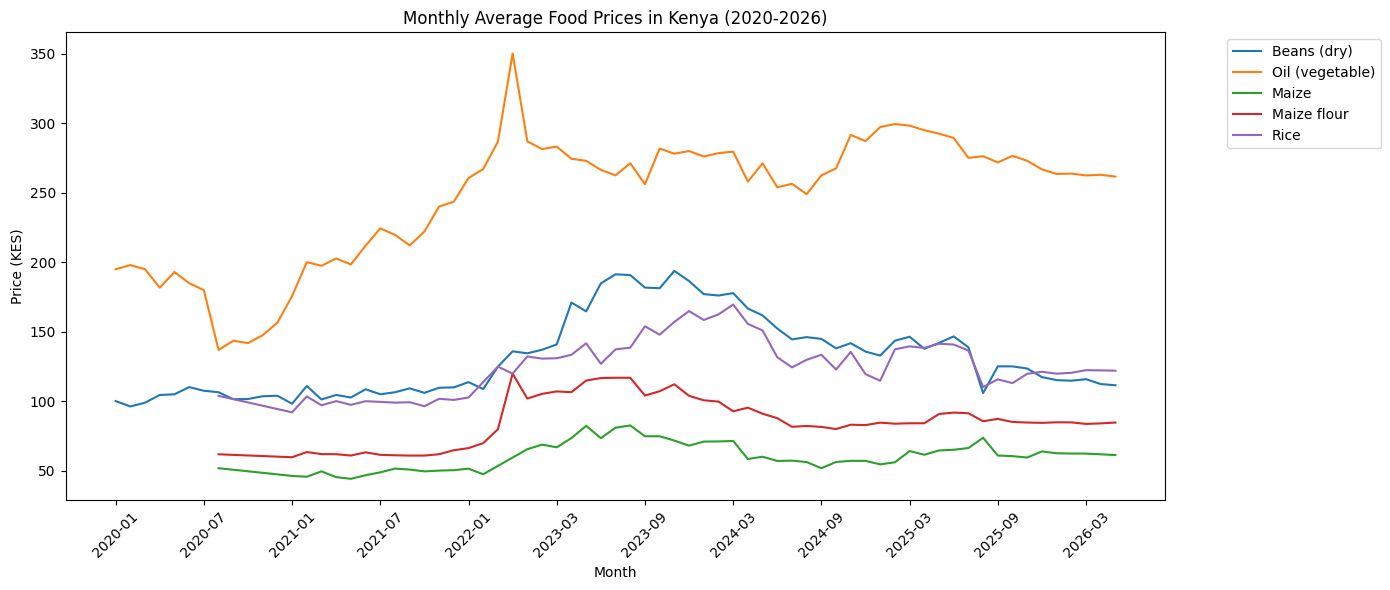

In [7]:
#Visualize the trends for the top 5 commodities

import seaborn as sns
import matplotlib.pyplot as plt

# Convert year_month to string for plotting
top5 = monthly_avg_price[monthly_avg_price['commodity'].isin(['Beans (dry)','Oil (vegetable)','Rice','Maize flour','Maize'])]
top5 = top5.copy()
top5['year_month'] = top5['year_month'].astype(str)

plt.figure(figsize=(14,6))
sns.lineplot(data=top5, x='year_month', y='price', hue='commodity')

ticks = top5['year_month'].unique()[::6]
plt.xticks(ticks=range(0, len(top5['year_month'].unique()), 6), labels=ticks, rotation=45)

plt.title('Monthly Average Food Prices in Kenya (2020-2026)')
plt.xlabel('Month')
plt.ylabel('Price (KES)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('trend_chart.png', bbox_inches='tight')
plt.show()

         admin_1       price
3  North Eastern  142.480895
1        Eastern  141.455285
4    Rift Valley  140.720140
0          Coast  127.477697
2        Nairobi  103.679562


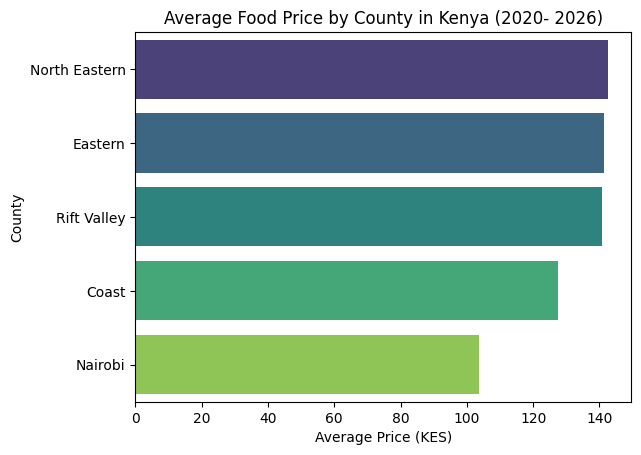

In [8]:
# Calulate the average price for each county

avg_price_county = df.groupby(['admin_1'])['price'].mean().reset_index().sort_values(by='price',ascending=False)
print(avg_price_county)

sns.barplot(data=avg_price_county, x='price',y='admin_1',hue='admin_1',palette='viridis',legend=False)
plt.title('Average Food Price by County in Kenya (2020- 2026)')
plt.xlabel('Average Price (KES)')
plt.ylabel('County')

plt.savefig('county_chart.png', bbox_inches='tight')
plt.show()

                     commodity      price
8            Milk (cow, fresh)  56.453960
9              Oil (vegetable)  39.302743
2                         Kale  38.260925
10  Oil (vegetable, fortified)  36.789344
1                  Beans (dry)  31.837843
0                        Beans  28.991586
11                        Rice  27.770200
5           Maize (white, dry)  21.778732
6                  Maize flour  19.341652
7          Maize flour (white)  18.967019
4                Maize (white)  15.707722
3                        Maize  13.404368
12                    Tomatoes        NaN


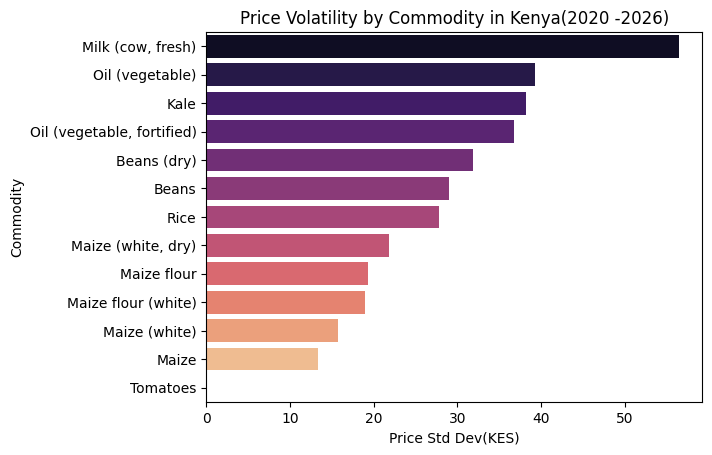

In [9]:
# Calculate the price volatility (std dev ) for each commodity

avg_price_commodity =df.groupby('commodity')['price'].std().reset_index().sort_values(by='price',ascending=False)
print(avg_price_commodity)

sns.barplot(data=avg_price_commodity,x='price',y='commodity',hue='commodity',palette='magma',legend=False)
plt.title('Price Volatility by Commodity in Kenya(2020 -2026)')
plt.xlabel('Price Std Dev(KES)')
plt.ylabel('Commodity')
plt.savefig('volatility_chart.png', bbox_inches='tight')
plt.show()

# Time Series Forecast With Prophet

In [10]:
# Time Series forecasting with Prophet

from prophet import Prophet

# filter the data for maize flour

maize_flour_df = monthly_avg_price[monthly_avg_price['commodity'] == 'Maize flour']

# prepare the data for prophet

df_maize = maize_flour_df.rename(columns={'year_month': 'ds','price':'y'})

df_maize = df_maize.drop(columns=['commodity'])

df_maize['ds'] = df_maize['ds'].dt.to_timestamp()
print(df_maize.head())
print(df_maize.dtypes)





c:\Users\TEST\Downloads\Kenya-Food-Price Analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


           ds          y
25 2020-08-01  62.000000
45 2021-01-01  59.881933
53 2021-02-01  63.587070
60 2021-03-01  62.145633
66 2021-04-01  62.051274
ds    datetime64[us]
y            float64
dtype: object


In [11]:
# Fit the Prophet model and make predictions for the next 12 months

model = Prophet()

model.fit(df_maize)

# create a df for future prediction 
future = model.make_future_dataframe(periods=12, freq='MS')


forecast = model.predict(future)
print(forecast[['ds', 'yhat','yhat_lower','yhat_upper']])

16:41:05 - cmdstanpy - INFO - Chain [1] start processing
16:41:06 - cmdstanpy - INFO - Chain [1] done processing


           ds       yhat  yhat_lower  yhat_upper
0  2020-08-01  51.886817   41.966244   61.013250
1  2021-01-01  57.643274   47.577359   67.516234
2  2021-02-01  60.652205   51.341077   70.870799
3  2021-03-01  60.697504   50.774206   71.075851
4  2021-04-01  63.186681   53.938202   73.094350
..        ...        ...         ...         ...
65 2027-01-01  74.229966   63.884112   84.144894
66 2027-02-01  74.301989   63.734379   84.440873
67 2027-03-01  75.240427   64.693186   85.549347
68 2027-04-01  72.442057   62.641684   82.326007
69 2027-05-01  76.945006   66.130540   86.646645

[70 rows x 4 columns]


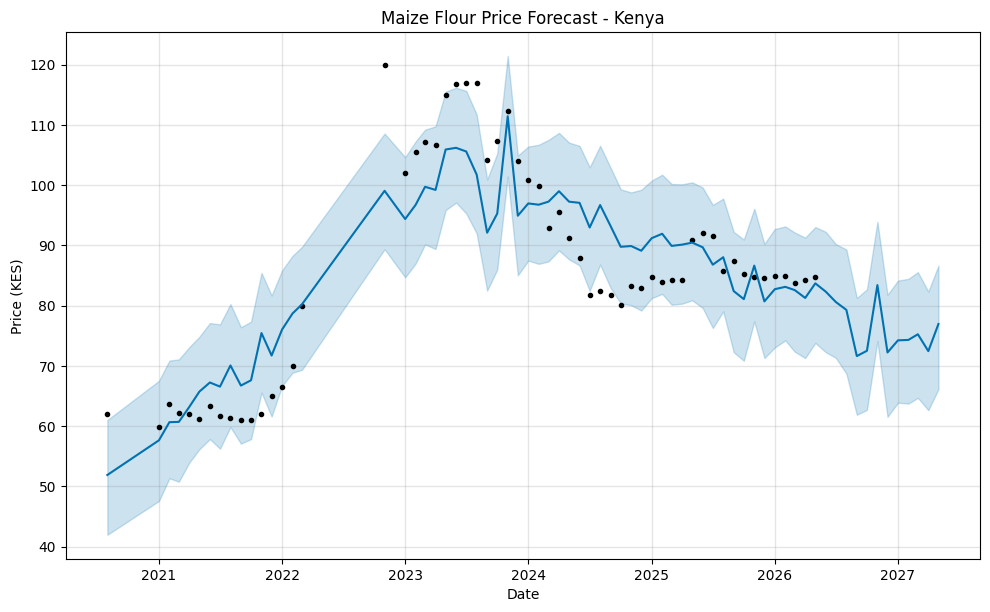

In [12]:
# visualize the forecast
fig = model.plot(forecast)
plt.title('Maize Flour Price Forecast - Kenya')
plt.xlabel('Date')
plt.ylabel('Price (KES)')
plt.show()